# Recursion Animation

Visualise how **token-choice MoR** routes generated tokens across recursion depths.

For each of **3 unconditional samples** we generate all 4 modalities (`tok_rgb@256`, `tok_depth@256`, `tok_normal@256`, `caption`). Each generated token is assigned a recursion depth (1–3) by the MoR router. The animation reveals tokens progressively:

| Frame | What is shown |
|-------|---------------|
| 1 | depth-1 tokens only — fewest recursion passes |
| 2 | depth-1 **+** depth-2 tokens |
| 3 | all tokens (depth-1 + 2 + 3) — full generation |

For **visual modalities** (RGB, depth, normal) unrevealed 16×16 patches are shown as gray until their depth threshold is reached.  
For **caption** each GPT-2 token piece is coloured by its depth assignment (green → blue → red).

GIFs are saved under `results/animations/`.

## 1. Environment + imports

In [1]:
import os
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')

from pathlib import Path
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_DIR)

# ── HF env — must be set before any transformers/huggingface_hub imports ──────
from util.env import load_dotenv
load_dotenv()
from paths import HF_CACHE_DIR
os.environ.setdefault('HF_HOME', HF_CACHE_DIR)
os.environ.setdefault('HF_HUB_OFFLINE', '1')
os.environ.setdefault('TRANSFORMERS_OFFLINE', '1')

# DTensor workaround — same as infer.py (needed for transformers 4.52.4 + single-GPU).
try:
    from torch.distributed.tensor import DTensor
except ImportError:
    class DTensor: pass
import transformers.modeling_utils
transformers.modeling_utils.DTensor = DTensor

import io
import numpy as np
import torch
import matplotlib
matplotlib.use('Agg')  # headless — avoids Qt/Tk issues in notebooks on some systems
import matplotlib.pyplot as plt
from PIL import Image as PILImage

from omegaconf import open_dict
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from transformers import AutoTokenizer, StoppingCriteria, StoppingCriteriaList

from model.util import load_model_from_config, load_checkpoint
from model.sharing_strategy import SHARING_STRATEGY
from util.config import preprocess_config
from lm_dataset.multimodal_vocab_shared_caption_scene_desc import MODALITIES, PAD_ID
from visualization.decode import _resolve_cosmos_decoder_jit

print('Modalities in vocab:', list(MODALITIES.keys()))
print('PAD_ID:', PAD_ID)

/home/mahliaM/miniconda3/envs/mor/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modalities in vocab: ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'caption', 'scene_desc']
PAD_ID: 242270


## 2. Load model

Uses `gbasi18/MoR-5000-Multimodality-all-modalities` — **token-choice MoR** (`rand_router=False`) trained on all four modalities with `num_recursion=3`.  
Change `CHECKPOINT` to swap in a different checkpoint without touching anything else.

In [2]:
# ── Checkpoint + runtime knobs (edit here to swap models) ────────────────────
CHECKPOINT  = 'hf_cache/models--gbasi18--MoR-5000-Multimodality-all-modalities/snapshots/837cbe67df057b50040122bf721d1b03cc66bfaa'
PATCH_GRID  = 16          # 16×16 = 256 image tokens per modality
COSMOS_PATH = 'pretrained_ckpts/Cosmos-0.1-Tokenizer-DI16x16'
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Compose the matching training config (defines model architecture) ─────────
if GlobalHydra().is_initialized():
    GlobalHydra().clear()

with initialize_config_dir(config_dir=str(PROJECT_DIR / 'conf'), version_base=None):
    cfg = compose(config_name='pretrain_vision/multimodal_training/110526_multimodal_training_final')

with open_dict(cfg):
    cfg.wandb = False
    cfg.wandb_entity = ''
    cfg.wandb_project = 'inference'
    cfg.wandb_run_name = 'inference'
    cfg.resume_from_checkpoint = False
cfg = preprocess_config(cfg)

print(f'Building model on {DEVICE}...')

model = load_model_from_config(cfg)
if cfg.recursive.get('enable'):
    model, _ = SHARING_STRATEGY[cfg.model](cfg, model)
if 'kv_sharing' in cfg and cfg.kv_sharing.get('enable'):
    model.set_kv_sharing_config(cfg)
if 'mor' in cfg and cfg.mor.get('enable'):
    if cfg.mor.type == 'expert':
        model.transform_layer_to_mor_expert(cfg)
    elif cfg.mor.type == 'token':
        model.transform_layer_to_mor_token(cfg)

model = load_checkpoint(model, CHECKPOINT)
model.to(DEVICE).eval()

NUM_RECURSION = cfg.recursive.num_recursion
GPT2_TOK      = AutoTokenizer.from_pretrained('gpt2', local_files_only=True)

print(f'Model ready.  layers={model.config.num_hidden_layers}  '
      f'num_recursion={NUM_RECURSION}  patch_grid={PATCH_GRID}')

-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : multimodal_training_final
Using deepspeed config = /home/mahliaM/Mixture-of-Recursions-for-Vision/ds_configs/stage2.config
--------------------------------------------------------------------------------
Building model on cuda...
Initializing model from scratch...
Using custom config for vanilla model...
 num_hidden_layers: 29
 vocab_size: 242271


/home/mahliaM/Mixture-of-Recursions-for-Vision/util/config.py:95: UserWarning: stop_steps (19500) is not divisible by save_steps (5000)
  warnings.warn(warning)
/home/mahliaM/Mixture-of-Recursions-for-Vision/model/util.py:90: UserWarning: original max_position_embeddings of 2048 is changed to 1048
  warnings.warn(f"original max_position_embeddings of {config.max_position_embeddings} is changed to {cfg.max_length}")


Model ready.  layers=29  num_recursion=3  patch_grid=16


## 3. Helpers — Cosmos decoder, generation, routing

In [3]:
# ── Cosmos image decoder (cached singleton) ──────────────────────────────────
_cosmos_decoder = None

def _get_cosmos_decoder():
    global _cosmos_decoder
    if _cosmos_decoder is None:
        from cosmos_tokenizer.image_lib import ImageTokenizer
        decoder_jit = _resolve_cosmos_decoder_jit(COSMOS_PATH)
        _cosmos_decoder = ImageTokenizer(
            checkpoint_dec=decoder_jit, device='cuda', dtype='bfloat16'
        )
    return _cosmos_decoder


def decode_image_tokens(raw_tokens: np.ndarray) -> np.ndarray | None:
    """raw_tokens: (PATCH_GRID**2,) int VQ indices  →  HxWx3 uint8, or None."""
    if raw_tokens.size != PATCH_GRID * PATCH_GRID:
        return None
    if DEVICE != 'cuda' or not torch.cuda.is_available():
        print('  [warn] Cosmos decode requires CUDA.')
        return None
    tok = _get_cosmos_decoder()
    idx = (
        torch.from_numpy(raw_tokens.astype(np.int64))
        .reshape(1, PATCH_GRID, PATCH_GRID)
        .to('cuda')
    )
    with torch.no_grad():
        dec = tok.decode(idx).float().cpu().numpy()[0]  # (3, H, W) in ~[-1, 1]
    dec = np.clip((dec + 1.0) / 2.0, 0.0, 1.0)
    return (dec.transpose(1, 2, 0) * 255.0 + 0.5).astype(np.uint8)


# ── Generation + routing ──────────────────────────────────────────────────────
class _EoStopping(StoppingCriteria):
    def __init__(self, eo_id): self.eo_id = eo_id
    def __call__(self, input_ids, scores, **kwargs):
        return bool((input_ids[:, -1] == self.eo_id).all())


def generate_with_depths(
    target_modality: str,
    seed: int = 0,
    do_sample: bool = True,
    temperature: float = 0.9,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Unconditionally generate one sequence for `target_modality`, then run a
    no-cache forward pass to collect token-choice MoR routing decisions.

    Returns
    -------
    body_tokens : 1-D LongTensor — generated body tokens in unified vocab
    avg_depth   : 1-D LongTensor — per-token recursion depth ∈ [1, NUM_RECURSION],
                  averaged across all MoR layers and rounded to nearest integer
    """
    info    = MODALITIES[target_modality]
    max_new = 257 if info.data_type == 'tokens' else 65  # 256 body + EO  /  64 text + EO
    prompt  = torch.tensor([[info.bo_id]], dtype=torch.long).to(DEVICE)

    if seed is not None:
        torch.manual_seed(seed)

    with torch.no_grad():
        out = model.generate(
            input_ids=prompt,
            attention_mask=torch.ones_like(prompt),
            max_new_tokens=max_new,
            use_cache=False,
            stopping_criteria=StoppingCriteriaList([_EoStopping(info.eo_id)]),
            do_sample=do_sample or temperature != 1.0,
            temperature=temperature,
            pad_token_id=PAD_ID,
        )

    # ── collect routing decisions (token-choice) via forward hooks ──
    captured: list[torch.Tensor] = []

    def _hook(_m, _i, output):
        tei = getattr(output, 'token_expert_indices', None)
        if tei is not None:
            captured.append(tei.detach().cpu())

    handles = [
        m.register_forward_hook(_hook)
        for m in model.modules()
        if getattr(m, 'mor', False)
    ]
    try:
        with torch.no_grad():
            model(input_ids=out, use_cache=False)
    finally:
        for h in handles:
            h.remove()

    if not captured:
        raise RuntimeError('No MoR layers captured — check that mor.enable=true in config.')

    # depth: (num_mor_layers, T) with values in [1, NUM_RECURSION]
    depth = torch.stack([t[0] for t in captured], dim=0).long() + 1

    # Locate body token slice [BO+1 : EO] in the generated sequence
    out_1d     = out[0].cpu()
    bo_pos     = int((out_1d == info.bo_id).nonzero(as_tuple=False)[0].item())
    eo_mask    = out_1d == info.eo_id
    eo_pos     = int(eo_mask.nonzero(as_tuple=False)[0].item()) if eo_mask.any() else out_1d.shape[0]
    body_start = bo_pos + 1
    body_end   = eo_pos

    body_tokens = out_1d[body_start:body_end]
    body_depths = depth[:, body_start:body_end]  # (num_layers, num_body_tokens)

    # Average across MoR layers, round to nearest int, clamp to valid range
    avg_depth = body_depths.float().mean(dim=0).round().long().clamp(1, NUM_RECURSION)

    return body_tokens, avg_depth


print('Helpers ready.')

Helpers ready.


## 4. Animation builders

In [4]:
from matplotlib import font_manager as _fm
_fm.fontManager.addfont('/home/mahliaM/.fonts/NotoSans-Regular.ttf')
_fm.fontManager.addfont('/home/mahliaM/.fonts/NotoSans-Bold.ttf')

_FONT = 'Noto Sans'
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': [_FONT]})

# Depth colour palette (matplotlib hex strings)
_DEPTH_COLORS = {
    1: '#2ca02c',   # green  — fewest recursion passes
    2: '#1f77b4',   # blue   — medium
    3: '#d62728',   # red    — most passes (highest compute)
}


def _make_visual_frame(
    full_image: np.ndarray,
    depth_grid: np.ndarray,
    threshold: int,
    gray_val: int = 255,
) -> np.ndarray:
    """
    Reveal image patches where depth_grid[r, c] <= threshold.
    All other patches are filled with a flat gray.

    full_image  : (H, W, 3) uint8
    depth_grid  : (PATCH_GRID, PATCH_GRID) int in [1, NUM_RECURSION]
    """
    H, W  = full_image.shape[:2]
    ph    = H // PATCH_GRID
    pw    = W // PATCH_GRID
    frame = np.full_like(full_image, gray_val)
    for r in range(PATCH_GRID):
        for c in range(PATCH_GRID):
            if depth_grid[r, c] <= threshold:
                r0, r1 = r * ph, (r + 1) * ph
                c0, c1 = c * pw, (c + 1) * pw
                frame[r0:r1, c0:c1] = full_image[r0:r1, c0:c1]
    return frame


def _fig_to_pil(fig: plt.Figure) -> PILImage.Image:
    """Render a matplotlib Figure to a PIL Image (RGB)."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
    buf.seek(0)
    img = PILImage.open(buf).convert('RGB').copy()
    plt.close(fig)
    return img


def build_animation_frames(
    sample_data: dict,
    num_recursions: int = 3,
) -> list:
    """
    Build one PIL Image per recursion threshold (1 … num_recursions).

    sample_data maps modality_name -> dict with:
        body_tokens : LongTensor  — generated body tokens in unified vocab
        avg_depth   : LongTensor  — per-token depth in [1, num_recursions]
        image       : np.ndarray | None  (visual modalities only)
    """
    MODALITY_ORDER  = ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'caption']
    MODALITY_LABELS = ['RGB', 'Depth', 'Normal', 'Caption']

    frames = []
    for threshold in range(0, num_recursions + 1):
        fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
        for ax, mod, label in zip(axes, MODALITY_ORDER, MODALITY_LABELS):
            data = sample_data.get(mod)
            if data is None:
                ax.axis('off')
                continue

            info = MODALITIES[mod]

            if info.data_type == 'tokens':
                # ── visual modality: reveal patches by depth ──
                full_img = data.get('image')
                if full_img is None:
                    ax.imshow(np.full((256, 256, 3), 160, dtype=np.uint8))
                    ax.set_title(f'{label}\n(decode failed)', fontsize=9)
                else:
                    depth_grid = (
                        data['avg_depth'][: PATCH_GRID * PATCH_GRID]
                        .numpy()
                        .reshape(PATCH_GRID, PATCH_GRID)
                    )
                    ax.imshow(_make_visual_frame(full_img, depth_grid, threshold))
                    ax.set_title(label, fontsize=10)

            else:
                # ── text modality: colour each token piece by depth ──
                raw_ids = (data['body_tokens'] - info.codebook_offset).cpu().tolist()
                depths  = data['avg_depth'].tolist()

                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                ax.set_aspect('equal', adjustable='box')
                ax.set_facecolor('white')

                x, y       = 0.03, 0.95
                line_chars = 0
                max_chars  = 32   # characters per line before wrapping
                line_h     = 0.075
                char_w     = 0.027

                for tok_id, d in zip(raw_ids, depths):
                    piece = GPT2_TOK.decode([tok_id])
                    if not piece:
                        continue
                    color = _DEPTH_COLORS.get(d, '#222222') if d <= threshold else '#ffffff'
                    if line_chars + len(piece) > max_chars and line_chars > 0:
                        y -= line_h
                        x, line_chars = 0.04, 0
                        if y < 0.02:
                            ax.text(0.5, 0.01, '…', ha='center', va='bottom',
                                    fontsize=7, family=_FONT, transform=ax.transAxes)
                            break
                    ax.text(x, y, piece,
                            color=color, fontsize=9,
                            family=_FONT,
                            transform=ax.transAxes, va='top')
                    x         += len(piece) * char_w
                    line_chars += len(piece)

                ax.set_title(label, fontsize=10)

            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

        plt.tight_layout(pad=0.4, w_pad=0.4)
        frames.append(_fig_to_pil(fig))

    return frames


def save_animation_gif(
    frames: list,
    output_path: str,
    frame_ms: int = 1500,
    final_ms: int = 3500,
) -> None:
    """Save a list of PIL Images as a looping animated GIF."""
    durations = [frame_ms] * (len(frames) - 1) + [final_ms]
    frames[0].save(
        output_path,
        save_all=True,
        append_images=frames[1:],
        optimize=False,
        duration=durations,
        loop=0,
    )
    print(f'Saved → {output_path}  ({len(frames)} frames)')


print('Animation helpers ready.')

Animation helpers ready.


## 5. Generate samples and save GIFs

Change `SEEDS` or `TEMPERATURE` to vary the generations. Each run produces one GIF with 3 frames.


=== Sample 1 / 1  (seed=10) ===
  Generating tok_rgb@256...
    256 tokens  depth dist [149, 74, 33]  [OK]
  Generating tok_depth@256...
    256 tokens  depth dist [166, 24, 66]  [OK]
  Generating tok_normal@256...
    256 tokens  depth dist [33, 9, 214]  [OK]
  Generating caption...
    "The image depicts 10 objects: two large metal spheres (yellow and gray…"
    depth dist [16, 13, 36]
  Building animation frames...
Saved → results/animations/recursion_sample01.gif  (4 frames)


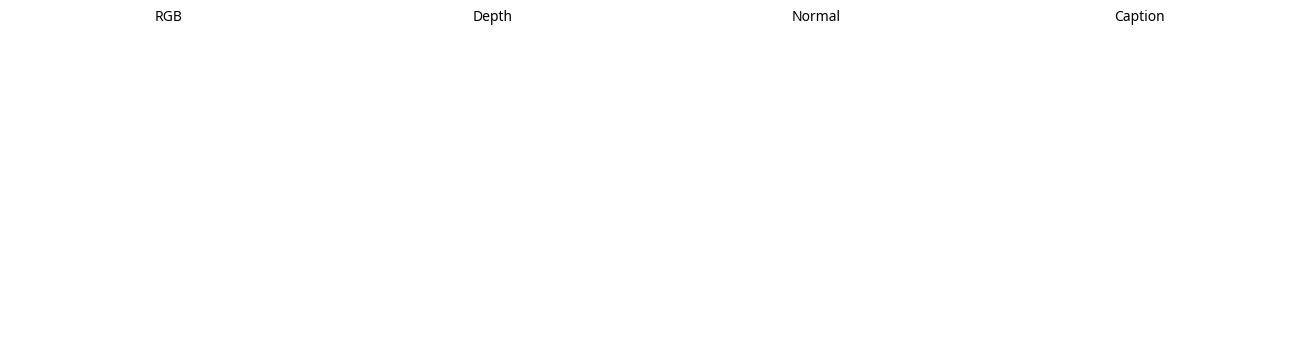

In [5]:
from IPython.display import display, Image as IPyImage

MODALITY_ORDER = ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'caption']

OUTPUT_DIR  = Path('results/animations')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEEDS       = [10]   # one GIF per seed
DO_SAMPLE   = True
TEMPERATURE = 0.9

ALL_SAMPLES = []

for sample_idx, seed in enumerate(SEEDS):
    print(f'\n=== Sample {sample_idx + 1} / {len(SEEDS)}  (seed={seed}) ===')
    sample_data = {}

    for modality in MODALITY_ORDER:
        print(f'  Generating {modality}...')
        body_tokens, avg_depth = generate_with_depths(
            modality,
            seed=seed,
            do_sample=DO_SAMPLE,
            temperature=TEMPERATURE,
        )
        info  = MODALITIES[modality]
        entry = {'body_tokens': body_tokens, 'avg_depth': avg_depth}

        if info.data_type == 'tokens':
            raw          = (body_tokens - info.codebook_offset).cpu().numpy()
            entry['image'] = decode_image_tokens(raw[: PATCH_GRID * PATCH_GRID])
            dist         = torch.bincount(avg_depth - 1, minlength=NUM_RECURSION).tolist()
            status       = 'OK' if entry['image'] is not None else 'DECODE FAILED'
            print(f'    {len(body_tokens)} tokens  depth dist {dist}  [{status}]')
        else:
            raw_ids        = (body_tokens - info.codebook_offset).cpu().tolist()
            text           = GPT2_TOK.decode(raw_ids, skip_special_tokens=True)
            entry['text']  = text
            dist           = torch.bincount(avg_depth - 1, minlength=NUM_RECURSION).tolist()
            preview        = text[:70] + ('…' if len(text) > 70 else '')
            print(f'    "{preview}"')
            print(f'    depth dist {dist}')

        sample_data[modality] = entry

    ALL_SAMPLES.append(sample_data)

    print('  Building animation frames...')
    frames = build_animation_frames(sample_data, num_recursions=NUM_RECURSION)

    gif_path = OUTPUT_DIR / f'recursion_sample{sample_idx + 1:02d}.gif'
    save_animation_gif(frames, str(gif_path))

    display(IPyImage(filename=str(gif_path)))

## 6. Per-modality GIFs

Split each sample into 4 single-modality GIFs (RGB, Depth, Normal, Caption) — same rendering as the combined figure, but each modality in its own file with its label on top.


=== Sample 1 / 1 ===
Saved → results/animations/recursion_sample01_tok_rgb_at_256.gif  (4 frames)


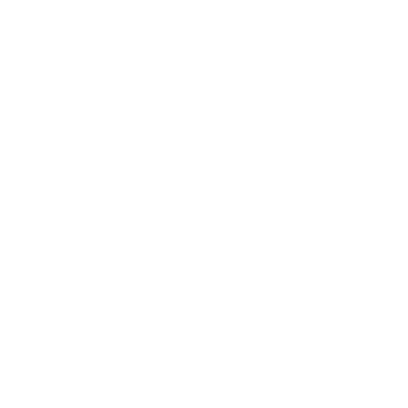

Saved → results/animations/recursion_sample01_tok_depth_at_256.gif  (4 frames)


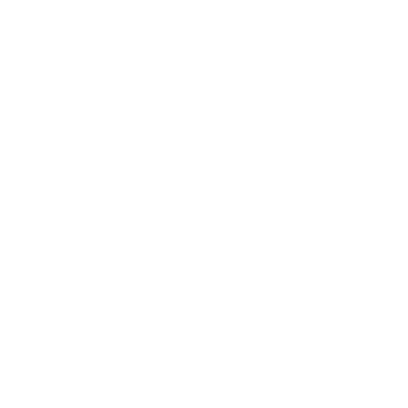

Saved → results/animations/recursion_sample01_tok_normal_at_256.gif  (4 frames)


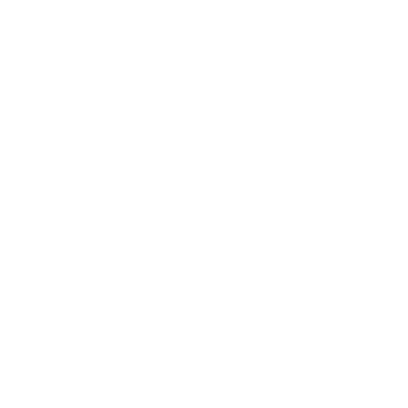

Saved → results/animations/recursion_sample01_caption.gif  (4 frames)


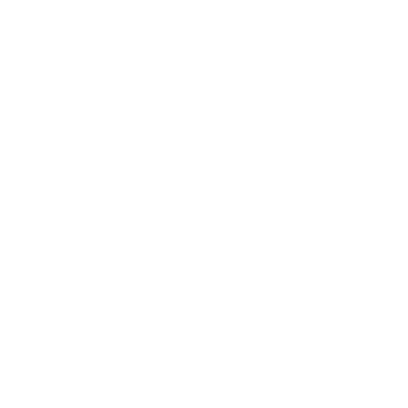

In [6]:
# Build & save per-modality GIFs from ALL_SAMPLES collected by the previous cell.
# Mirrors the per-panel rendering of build_animation_frames so style is identical.

MODALITY_LABELS = ['RGB', 'Depth', 'Normal', 'Caption']


def build_single_modality_frames(sample_data, modality, label, num_recursions=NUM_RECURSION):
    """Build one frame per recursion threshold for a single modality."""
    data = sample_data[modality]
    info = MODALITIES[modality]

    frames = []
    for threshold in range(0, num_recursions + 1):
        fig, ax = plt.subplots(figsize=(4, 4.2))

        if info.data_type == 'tokens':
            full_img = data.get('image')
            if full_img is None:
                ax.imshow(np.full((256, 256, 3), 0, dtype=np.uint8))
            else:
                depth_grid = (
                    data['avg_depth'][: PATCH_GRID * PATCH_GRID]
                    .numpy()
                    .reshape(PATCH_GRID, PATCH_GRID)
                )
                ax.imshow(_make_visual_frame(full_img, depth_grid, threshold))
        else:
            raw_ids = (data['body_tokens'] - info.codebook_offset).cpu().tolist()
            depths  = data['avg_depth'].tolist()

            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_aspect('equal', adjustable='box')
            ax.set_facecolor('white')

            x, y       = 0.03, 0.95
            line_chars = 0
            max_chars  = 32
            line_h     = 0.075
            char_w     = 0.027

            for tok_id, d in zip(raw_ids, depths):
                piece = GPT2_TOK.decode([tok_id])
                if not piece:
                    continue
                color = _DEPTH_COLORS.get(d, '#222222') if d <= threshold else '#ffffff'
                if line_chars + len(piece) > max_chars and line_chars > 0:
                    y -= line_h
                    x, line_chars = 0.03, 0
                    if y < 0.02:
                        ax.text(0.5, 0.01, '…', ha='center', va='bottom',
                                fontsize=7, family=_FONT, transform=ax.transAxes)
                        break
                ax.text(x, y, piece,
                        color=color, fontsize=12,
                        family=_FONT,
                        transform=ax.transAxes, va='top')
                x         += len(piece) * char_w
                line_chars += len(piece)

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        plt.tight_layout(pad=0.4)
        frames.append(_fig_to_pil(fig))

    return frames


for sample_idx, sample_data in enumerate(ALL_SAMPLES):
    print(f'\n=== Sample {sample_idx + 1} / {len(ALL_SAMPLES)} ===')
    for modality, label in zip(MODALITY_ORDER, MODALITY_LABELS):
        frames = build_single_modality_frames(sample_data, modality, label)
        safe_mod = modality.replace('@', '_at_').replace('/', '_')
        gif_path = OUTPUT_DIR / f'recursion_sample{sample_idx + 1:02d}_{safe_mod}.gif'
        save_animation_gif(frames, str(gif_path))
        display(IPyImage(filename=str(gif_path)))

## 7. Cross-modal animations

For every (input modality → output modality) pair, condition on a real CLEVR test sample's input and generate the output. Each animation is a 1×2 panel: input on the left (static), output on the right (progressively revealed by depth). GIFs are saved under `results/animations/cross_modal/input_<modality>/to_<modality>.gif`.

  rgb → depth
Saved → results/animations/cross_modal/input_rgb/to_depth/to_depth.gif  (4 frames)


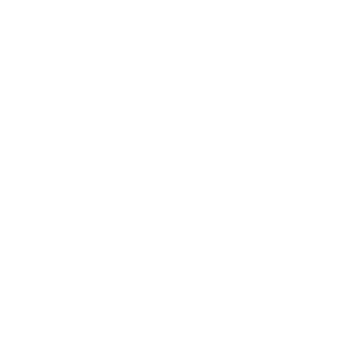

  rgb → normal
Saved → results/animations/cross_modal/input_rgb/to_normal/to_normal.gif  (4 frames)


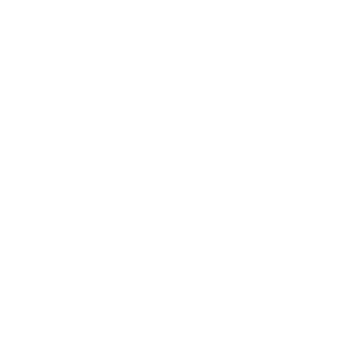

  rgb → caption
Saved → results/animations/cross_modal/input_rgb/to_caption/to_caption.gif  (4 frames)


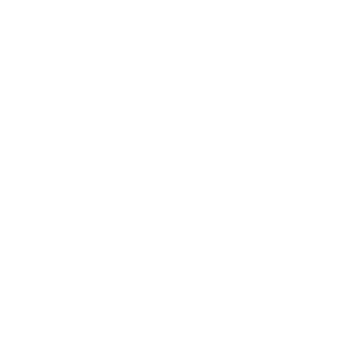

  depth → rgb
Saved → results/animations/cross_modal/input_depth/to_rgb/to_rgb.gif  (4 frames)


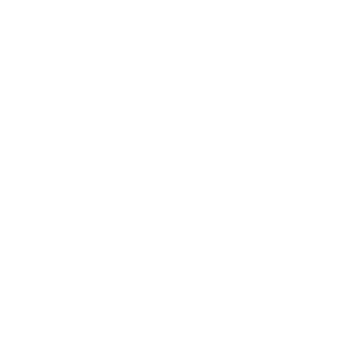

  depth → normal
Saved → results/animations/cross_modal/input_depth/to_normal/to_normal.gif  (4 frames)


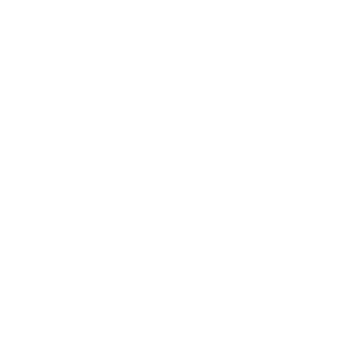

  depth → caption
Saved → results/animations/cross_modal/input_depth/to_caption/to_caption.gif  (4 frames)


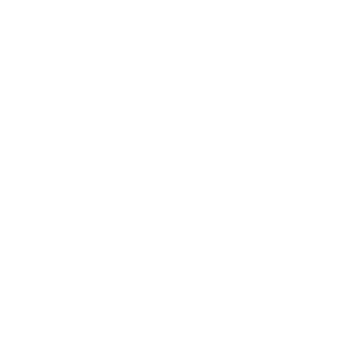

  normal → rgb
Saved → results/animations/cross_modal/input_normal/to_rgb/to_rgb.gif  (4 frames)


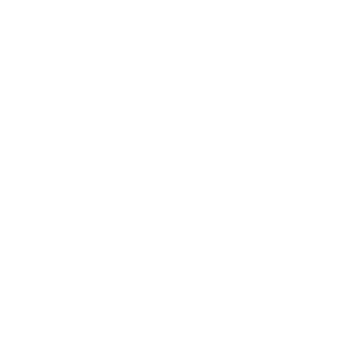

  normal → depth
Saved → results/animations/cross_modal/input_normal/to_depth/to_depth.gif  (4 frames)


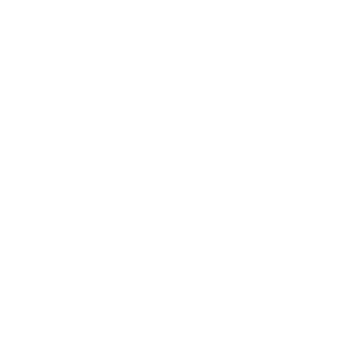

  normal → caption
Saved → results/animations/cross_modal/input_normal/to_caption/to_caption.gif  (4 frames)


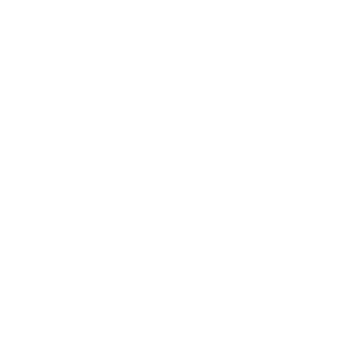

  caption → rgb
Saved → results/animations/cross_modal/input_caption/to_rgb/to_rgb.gif  (4 frames)


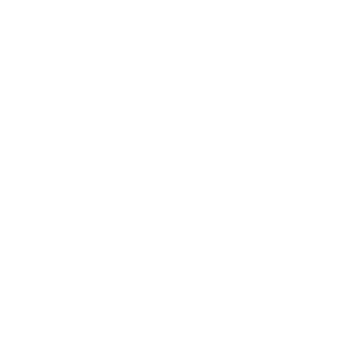

  caption → depth
Saved → results/animations/cross_modal/input_caption/to_depth/to_depth.gif  (4 frames)


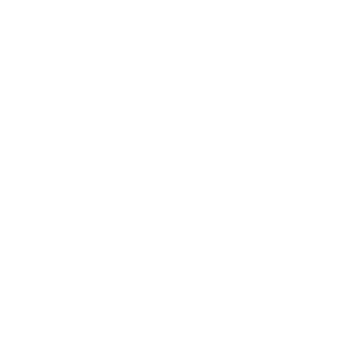

  caption → normal
Saved → results/animations/cross_modal/input_caption/to_normal/to_normal.gif  (4 frames)


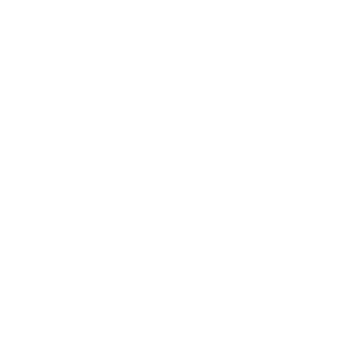

In [7]:
# Cross-modal: every modality → every other modality.
# Conditioning uses a real CLEVR test sample (not model-generated).

import json as _json
import textwrap as _textwrap

SAMPLE_ID = '00000'    # which CLEVR test sample to use as conditioning
AUG_IDX   = 0          # which of the K augmentations
CROSS_SEED = 0
CROSS_TEMPERATURE = 0.9

DATA_TEST   = Path('data/clevr_dataset/test')
TEXT_MAX_LEN = cfg.multimodal.get('text_max_length', 64)

CROSS_DIR = OUTPUT_DIR / 'cross_modal'
CROSS_DIR.mkdir(parents=True, exist_ok=True)

# Pretty slug used for folder + file names.
_SLUG = {
    'tok_rgb@256':    'rgb',
    'tok_depth@256':  'depth',
    'tok_normal@256': 'normal',
    'caption':        'caption',
}

# Load reference inputs ────────────────────────────────────────────────────────
ref_arrays = {
    'tok_rgb@256':    np.load(DATA_TEST / 'tok_rgb@256'    / f'{SAMPLE_ID}.npy')[AUG_IDX],
    'tok_depth@256':  np.load(DATA_TEST / 'tok_depth@256'  / f'{SAMPLE_ID}.npy')[AUG_IDX],
    'tok_normal@256': np.load(DATA_TEST / 'tok_normal@256' / f'{SAMPLE_ID}.npy')[AUG_IDX],
}
with open(DATA_TEST / 'caption' / f'{SAMPLE_ID}.json', encoding='utf-8') as _f:
    ref_caption_text = _json.load(_f)[AUG_IDX]

# Decode reference images for display (Cosmos).
ref_images = {
    mod: decode_image_tokens(np.asarray(arr).flatten()[:PATCH_GRID * PATCH_GRID])
    for mod, arr in ref_arrays.items()
}

# Chunk builders (mirror the inference notebook) ──────────────────────────────
def _chunk_text(modality, text):
    info = MODALITIES[modality]
    ids = GPT2_TOK(text, truncation=True, max_length=TEXT_MAX_LEN,
                   return_tensors='pt')['input_ids'][0].long()
    return torch.cat([
        torch.tensor([info.bo_id]),
        ids + info.codebook_offset,
        torch.tensor([info.eo_id]),
    ])

def _chunk_tokens(modality, arr):
    info = MODALITIES[modality]
    body = torch.from_numpy(np.asarray(arr).flatten()).long() + info.codebook_offset
    return torch.cat([
        torch.tensor([info.bo_id]),
        body,
        torch.tensor([info.eo_id]),
    ])

def _build_input_chunk(modality):
    if MODALITIES[modality].data_type == 'tokens':
        return _chunk_tokens(modality, ref_arrays[modality])
    return _chunk_text(modality, ref_caption_text)


def generate_conditional_with_depths(input_chunk, target_modality,
                                     seed=0, do_sample=True, temperature=0.9):
    """Conditional version of generate_with_depths. Returns the output slice only."""
    info = MODALITIES[target_modality]
    max_new = 257 if info.data_type == 'tokens' else 65
    prompt = torch.cat([input_chunk, torch.tensor([info.bo_id])]).unsqueeze(0).to(DEVICE)

    if seed is not None:
        torch.manual_seed(seed)

    with torch.no_grad():
        out = model.generate(
            input_ids=prompt,
            attention_mask=torch.ones_like(prompt),
            max_new_tokens=max_new,
            use_cache=False,
            stopping_criteria=StoppingCriteriaList([_EoStopping(info.eo_id)]),
            do_sample=do_sample or temperature != 1.0,
            temperature=temperature,
            pad_token_id=PAD_ID,
        )

    captured = []
    def _hook(_m, _i, output):
        tei = getattr(output, 'token_expert_indices', None)
        if tei is not None:
            captured.append(tei.detach().cpu())
    handles = [m.register_forward_hook(_hook)
               for m in model.modules() if getattr(m, 'mor', False)]
    try:
        with torch.no_grad():
            model(input_ids=out, use_cache=False)
    finally:
        for h in handles:
            h.remove()
    if not captured:
        raise RuntimeError('No MoR layers captured.')
    depth = torch.stack([t[0] for t in captured], dim=0).long() + 1

    out_1d = out[0].cpu()
    bo_positions = (out_1d == info.bo_id).nonzero(as_tuple=False).flatten()
    bo_pos = int(bo_positions[-1].item())
    body_start = bo_pos + 1
    eo_positions = (out_1d == info.eo_id).nonzero(as_tuple=False).flatten()
    eo_after = [int(p.item()) for p in eo_positions if int(p.item()) > bo_pos]
    body_end = eo_after[0] if eo_after else out_1d.shape[0]

    body_tokens = out_1d[body_start:body_end]
    body_depths = depth[:, body_start:body_end]
    avg_depth = body_depths.float().mean(dim=0).round().long().clamp(1, NUM_RECURSION)
    return body_tokens, avg_depth


def _render_caption_static(ax, text, fontsize=11, line_spacing=1.6):
    """Render a plain text string as clean word-wrapped lines on ax."""
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_facecolor('white')
    lines = _textwrap.wrap(text, width=38)
    # Compute line height in axes fraction from fontsize + spacing.
    line_h = (fontsize * line_spacing) / (ax.get_figure().get_size_inches()[1] * 72)
    y = 1.0 - line_h
    for line in lines:
        if y < 0:
            ax.text(0.5, 0.01, '…', ha='center', va='bottom',
                    fontsize=9, family=_FONT, transform=ax.transAxes)
            break
        ax.text(0.05, y, line, color='#222222', fontsize=fontsize,
                family=_FONT, transform=ax.transAxes, va='top')
        y -= line_h
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


# Per-axis renderer — static visual/caption or animated output with depth colours.
def _render_panel(ax, modality, *, body_tokens=None, avg_depth=None,
                  image=None, text=None, threshold=None, reveal=True):
    info = MODALITIES[modality]
    if info.data_type == 'tokens':
        if image is None:
            ax.imshow(np.full((256, 256, 3), 0, dtype=np.uint8))
        elif reveal:
            depth_grid = (avg_depth[:PATCH_GRID * PATCH_GRID]
                          .numpy().reshape(PATCH_GRID, PATCH_GRID))
            ax.imshow(_make_visual_frame(image, depth_grid, threshold))
        else:
            ax.imshow(image)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    else:
        if not reveal:
            _render_caption_static(ax, text)
        else:
            # Animated: token-by-token, coloured by depth.
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.set_aspect('equal', adjustable='box')
            ax.set_facecolor('white')
            raw_ids = (body_tokens - info.codebook_offset).cpu().tolist()
            depths  = avg_depth.tolist()
            x, y = 0.03, 0.95
            line_chars = 0
            max_chars  = 32
            line_h     = 0.075
            char_w     = 0.027
            for tok_id, d in zip(raw_ids, depths):
                piece = GPT2_TOK.decode([tok_id])
                if not piece:
                    continue
                color = _DEPTH_COLORS.get(d, '#222222') if d <= threshold else '#ffffff'
                if line_chars + len(piece) > max_chars and line_chars > 0:
                    y -= line_h; x = 0.03; line_chars = 0
                    if y < 0.02:
                        ax.text(0.5, 0.01, '…', ha='center', va='bottom',
                                fontsize=7, family=_FONT, transform=ax.transAxes)
                        break
                ax.text(x, y, piece, color=color, fontsize=12,
                        family=_FONT, transform=ax.transAxes, va='top')
                x += len(piece) * char_w
                line_chars += len(piece)
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)


def _save_modality_png(path, modality, *, image=None, text=None):
    """Save a single modality as a standalone PNG.
    Visual modalities are saved as raw pixel images; captions as rendered text."""
    info = MODALITIES[modality]
    if info.data_type == 'tokens':
        if image is not None:
            PILImage.fromarray(image).save(path)
    else:
        fig, ax = plt.subplots(figsize=(3.5, 3.5))
        _render_caption_static(ax, text)
        fig.savefig(path, format='png', bbox_inches='tight', dpi=100)
        plt.close(fig)


def build_output_frames(output_mod, out_body, out_depth, out_image,
                        num_recursions=NUM_RECURSION):
    """Single-panel frames of the generated output only — used for the saved GIF."""
    frames = []
    for threshold in range(0, num_recursions + 1):
        fig, ax = plt.subplots(figsize=(3.5, 3.5))
        _render_panel(
            ax, output_mod,
            body_tokens=out_body, avg_depth=out_depth, image=out_image,
            threshold=threshold, reveal=True,
        )
        plt.tight_layout(pad=0.4)
        frames.append(_fig_to_pil(fig))
    return frames


# Run: every modality → every other modality ──────────────────────────────────
for input_mod in MODALITY_ORDER:
    in_folder = CROSS_DIR / f'input_{_SLUG[input_mod]}'
    in_folder.mkdir(parents=True, exist_ok=True)
    input_chunk = _build_input_chunk(input_mod)

    _save_modality_png(
        in_folder / 'input.png', input_mod,
        image=ref_images.get(input_mod),
        text=ref_caption_text if input_mod == 'caption' else None,
    )

    for output_mod in MODALITY_ORDER:
        if output_mod == input_mod:
            continue

        out_folder = in_folder / f'to_{_SLUG[output_mod]}'
        out_folder.mkdir(parents=True, exist_ok=True)

        info_out = MODALITIES[output_mod]
        _save_modality_png(
            out_folder / 'ground_truth.png', output_mod,
            image=ref_images.get(output_mod),
            text=ref_caption_text if output_mod == 'caption' else None,
        )

        print(f'  {_SLUG[input_mod]} → {_SLUG[output_mod]}')
        out_body, out_depth = generate_conditional_with_depths(
            input_chunk, output_mod,
            seed=CROSS_SEED, do_sample=DO_SAMPLE, temperature=CROSS_TEMPERATURE,
        )

        if info_out.data_type == 'tokens':
            raw = (out_body - info_out.codebook_offset).cpu().numpy()
            out_image = decode_image_tokens(raw[:PATCH_GRID * PATCH_GRID])
        else:
            out_image = None

        frames = build_output_frames(output_mod, out_body, out_depth, out_image)
        gif_path = out_folder / f'to_{_SLUG[output_mod]}.gif'
        save_animation_gif(frames, str(gif_path))
        display(IPyImage(filename=str(gif_path)))